# Causal Detection of Wellbeing Problems in Gamers

This notebook builds an end-to-end ML pipeline that:

- Validates and cleans data.
- Engineers a binary **wellbeing_problem** outcome.
- Trains and compares multiple classifiers.
- Estimates causal-style effects of heavy gaming on wellbeing risk.
- Visualizes model performance and interpretable drivers.

The approach aligns with the hackathon requirements in `HACK_GUIDELINES.md`: train from scratch, evaluate rigorously, and explain results clearly.


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
DATA_FILENAME = "Gaming and Mental Health.csv"
_candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for _root in _candidate_roots:
    _p = _root / "data" / DATA_FILENAME
    if _p.exists():
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        f"Could not locate dataset '{DATA_FILENAME}' in expected data/ folders from cwd={Path.cwd()}"
    )

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print(f"Using dataset: {DATA_PATH.resolve()}")


Using dataset: /home/nate/Projects/Dataquest26/data/Gaming and Mental Health.csv


## 1) Load data and validate schema

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")
raw_df.head(3)


Raw shape: (1000, 27)


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe


In [3]:
EXPECTED_COLUMNS = {
    "record_id",
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "sleep_hours",
    "sleep_quality",
    "sleep_disruption_frequency",
    "academic_work_performance",
    "grades_gpa",
    "work_productivity_score",
    "mood_state",
    "mood_swing_frequency",
    "withdrawal_symptoms",
    "loss_of_other_interests",
    "continued_despite_problems",
    "eye_strain",
    "back_neck_pain",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "gaming_addiction_risk_level",
}

actual_columns = set(raw_df.columns)
missing_cols = sorted(EXPECTED_COLUMNS - actual_columns)
extra_cols = sorted(actual_columns - EXPECTED_COLUMNS)

print(f"Missing expected columns: {missing_cols}")
print(f"Unexpected extra columns: {extra_cols}")
assert not missing_cols, "Dataset schema mismatch: expected columns are missing."

print("\nData types:")
print(raw_df.dtypes)

dup_record_ids = raw_df.duplicated(subset=["record_id"]).sum()
print(f"\nDuplicate record_id count: {dup_record_ids}")

missing_pct_raw = (raw_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct_raw.head(10)


Missing expected columns: []
Unexpected extra columns: []

Data types:
record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality                           str
sleep_disruption_frequency              str
academic_work_performance               str
grades_gpa                          float64
work_productivity_score             float64
mood_state                              str
mood_swing_frequency                    str
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exerc

work_productivity_score    32.6
grades_gpa                 24.6
record_id                   0.0
daily_gaming_hours          0.0
game_genre                  0.0
primary_game                0.0
gaming_platform             0.0
sleep_hours                 0.0
sleep_quality               0.0
age                         0.0
dtype: float64

## 2) Cleaning and data quality safeguards

In [4]:
df = raw_df.copy()

# Normalize string columns: trim and convert blank-like tokens to missing.
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype("string").str.strip()
    df[c] = df[c].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NA": pd.NA})

# Remove duplicate records by ID (first occurrence kept).
if "record_id" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=["record_id"], keep="first").reset_index(drop=True)
    print(f"Dropped duplicate rows by record_id: {before - len(df)}")

numeric_cols = [
    "age",
    "daily_gaming_hours",
    "sleep_hours",
    "grades_gpa",
    "work_productivity_score",
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Plausible-value clipping to reduce impact of obvious data-entry outliers.
valid_ranges = {
    "age": (10, 80),
    "daily_gaming_hours": (0, 24),
    "sleep_hours": (0, 24),
    "grades_gpa": (0, 4.3),
    "work_productivity_score": (1, 10),
    "weight_change_kg": (-30, 30),
    "exercise_hours_weekly": (0, 40),
    "social_isolation_score": (1, 10),
    "face_to_face_social_hours_weekly": (0, 80),
    "monthly_game_spending_usd": (0, 2000),
    "years_gaming": (0, 70),
}

for c, (lo, hi) in valid_ranges.items():
    df[c] = df[c].clip(lower=lo, upper=hi)

# Median imputation for numeric features.
for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# Mode imputation for categorical features.
cat_cols = [c for c in df.columns if c not in numeric_cols]
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print(f"Cleaned shape: {df.shape}")
print("Remaining missing values:", int(df.isna().sum().sum()))
df.head(3)


Dropped duplicate rows by record_id: 0
Cleaned shape: (1000, 27)
Remaining missing values: 0


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,5.0,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,2.53,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe


In [5]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
quality_report.sort_values("missing_pct", ascending=False).head(15)


,dtype,missing_count,missing_pct
record_id,string,0,0.0
age,int64,0,0.0
gender,string,0,0.0
daily_gaming_hours,float64,0,0.0
game_genre,string,0,0.0
primary_game,string,0,0.0
gaming_platform,string,0,0.0
sleep_hours,float64,0,0.0
sleep_quality,string,0,0.0
sleep_disruption_frequency,string,0,0.0


## 3) Engineer target: wellbeing_problem

In [6]:
# Composite wellbeing target (binary):
# A participant is flagged if >=2 adverse wellbeing indicators are present.

negative_moods = {"Depressed", "Anxious", "Withdrawn"}
poor_sleep_levels = {"Very Poor", "Insomnia"}
poor_perf_levels = {"Poor", "Failing"}

df["adverse_mood"] = df["mood_state"].isin(negative_moods).astype(int)
df["adverse_sleep"] = df["sleep_quality"].isin(poor_sleep_levels).astype(int)
df["high_isolation"] = (df["social_isolation_score"] >= 7).astype(int)
df["low_social_contact"] = (df["face_to_face_social_hours_weekly"] <= 3).astype(int)
df["poor_performance"] = df["academic_work_performance"].isin(poor_perf_levels).astype(int)

df["wellbeing_problem_score"] = (
    df["adverse_mood"]
    + df["adverse_sleep"]
    + df["high_isolation"]
    + df["low_social_contact"]
    + df["poor_performance"]
)

df["wellbeing_problem"] = (df["wellbeing_problem_score"] >= 2).astype(int)

target_rate = df["wellbeing_problem"].mean()
print(f"Wellbeing problem prevalence: {target_rate:.3f} ({target_rate*100:.1f}%)")
print(df["wellbeing_problem"].value_counts())


Wellbeing problem prevalence: 0.271 (27.1%)
wellbeing_problem
0    729
1    271
Name: count, dtype: int64


## 4) Visualization: quality + risk patterns

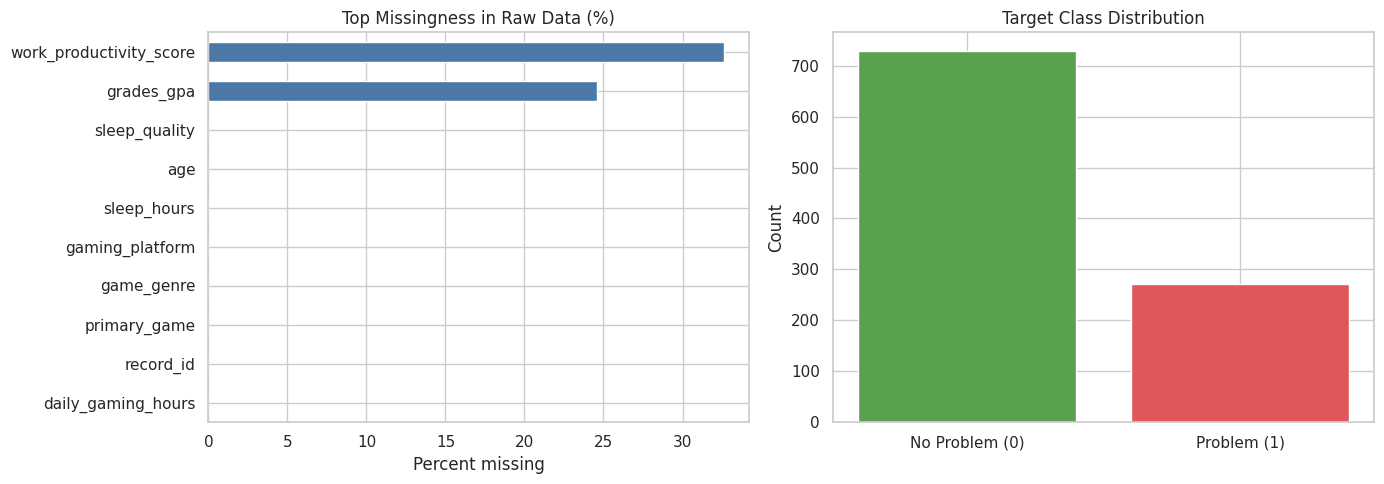

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missingness before cleaning.
missing_top = (raw_df.isna().mean() * 100).sort_values(ascending=False).head(10)
missing_top.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top Missingness in Raw Data (%)")
axes[0].set_xlabel("Percent missing")

# Target distribution.
target_counts = df["wellbeing_problem"].value_counts().sort_index()
axes[1].bar(["No Problem (0)", "Problem (1)"], target_counts.values, color=["#59A14F", "#E15759"])
axes[1].set_title("Target Class Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


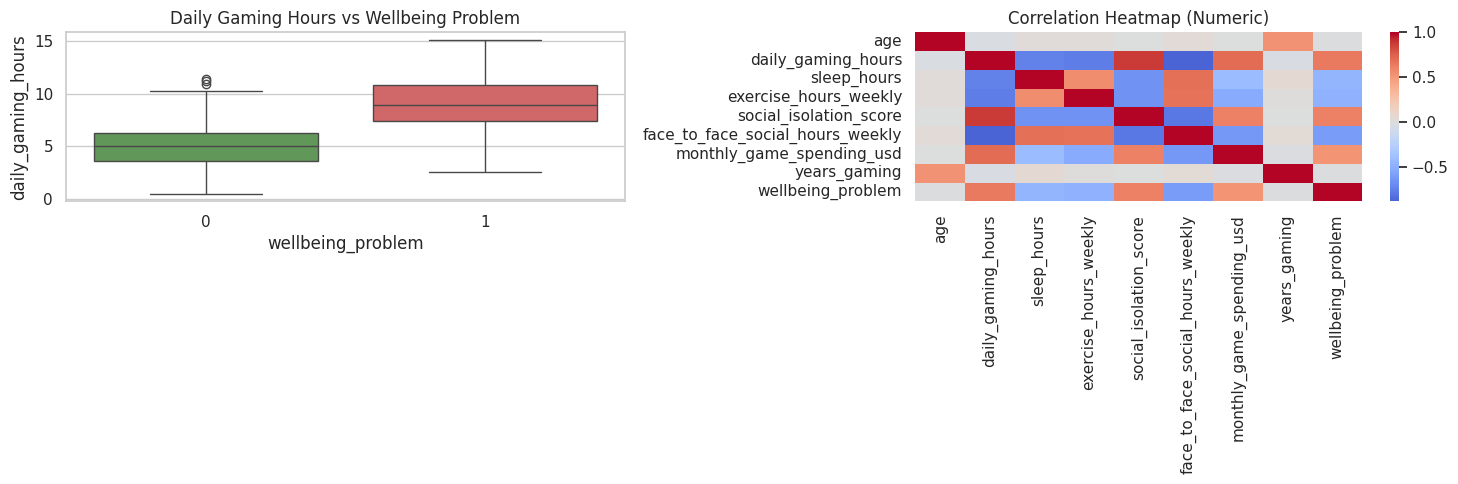

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=df,
    x="wellbeing_problem",
    y="daily_gaming_hours",
    ax=axes[0],
    palette=["#59A14F", "#E15759"],
)
axes[0].set_title("Daily Gaming Hours vs Wellbeing Problem")
axes[0].set_xlabel("wellbeing_problem")

corr_cols = [
    "age",
    "daily_gaming_hours",
    "sleep_hours",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "wellbeing_problem",
]

corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=axes[1])
axes[1].set_title("Correlation Heatmap (Numeric)")

plt.tight_layout()
plt.show()


## 5) Train multiple predictive models

In [9]:
# Cause-focused predictors only (to reduce leakage from symptom-style fields).
feature_cols = [
    "age",
    "gender",
    "daily_gaming_hours",
    "game_genre",
    "primary_game",
    "gaming_platform",
    "monthly_game_spending_usd",
    "years_gaming",
    "exercise_hours_weekly",
]

target_col = "wellbeing_problem"

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y,
)

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_features,
        ),
    ]
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
}

# Optional XGBoost model if available.
xgb_err = None
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=4,
    )
except Exception as exc:
    xgb_err = str(exc)
    print(f"XGBoost skipped: {xgb_err}")

trained_pipelines = {}
results = []
preds = {}
probas = {}
reports = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    trained_pipelines[model_name] = pipe
    preds[model_name] = y_pred
    probas[model_name] = y_proba
    reports[model_name] = classification_report(y_test, y_pred, output_dict=True)

    metrics_row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }
    results.append(metrics_row)

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.816,0.652778,0.691176,0.671429,0.898998
1,RandomForest,0.800,0.607143,0.750000,0.671053,0.898513
2,GradientBoosting,0.812,0.643836,0.691176,0.666667,0.897220
3,LogisticRegression,0.772,0.556701,0.794118,0.654545,0.888090


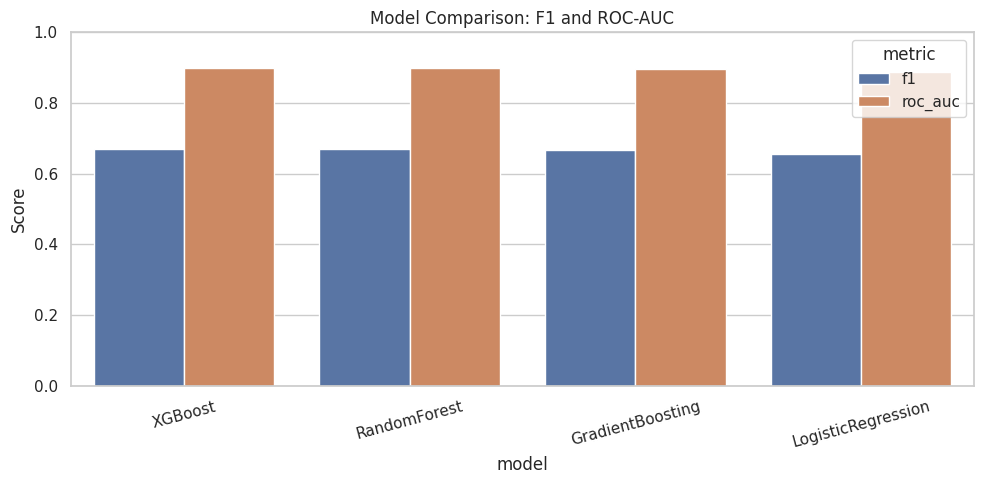

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.melt(id_vars="model", value_vars=["f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison: F1 and ROC-AUC")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Best model by F1: XGBoost
{'model': 'XGBoost', 'accuracy': 0.816, 'precision': 0.6527777777777778, 'recall': 0.6911764705882353, 'f1': 0.6714285714285714, 'roc_auc': 0.8989980607627667}


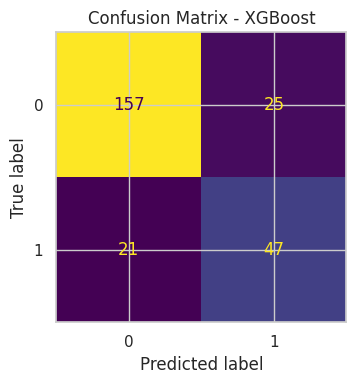

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = trained_pipelines[best_model_name]

print(f"Best model by F1: {best_model_name}")
print(results_df.iloc[0].to_dict())

cm = confusion_matrix(y_test, preds[best_model_name])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


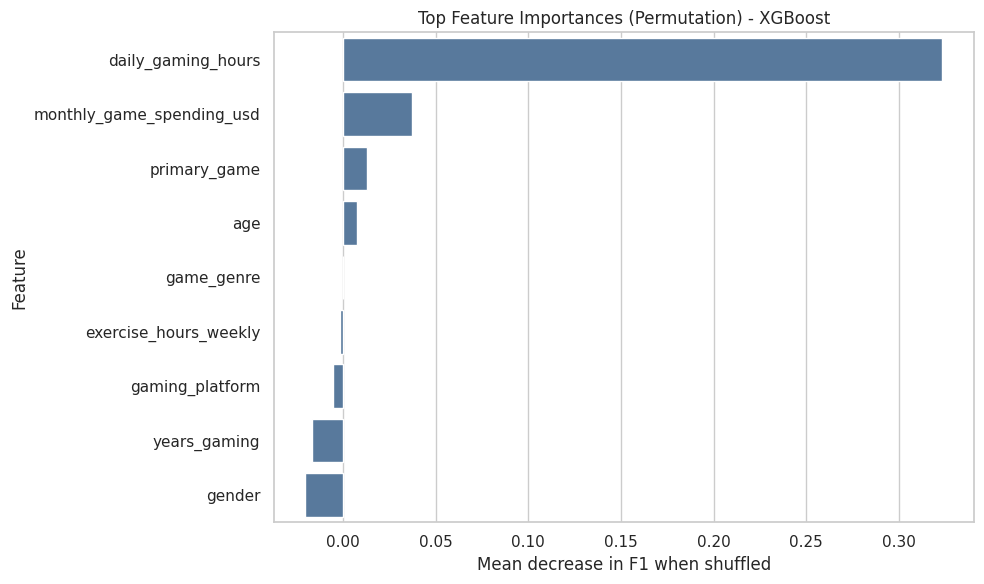

,feature,importance
2,daily_gaming_hours,0.323338
6,monthly_game_spending_usd,0.036978
4,primary_game,0.013022
0,age,0.007707
3,game_genre,-0.000073
8,exercise_hours_weekly,-0.001876
5,gaming_platform,-0.005264
7,years_gaming,-0.016934
1,gender,-0.020376


In [12]:
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="f1",
    n_jobs=-1,
)

# For a full pipeline, permutation importance aligns with the original input columns.
feature_names = X_test.columns.to_list()
perm_df = (
    pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=perm_df, y="feature", x="importance", ax=ax, color="#4C78A8")
ax.set_title(f"Top Feature Importances (Permutation) - {best_model_name}")
ax.set_xlabel("Mean decrease in F1 when shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

perm_df.head(10)


## 6) Causal detection: effect of heavy gaming on wellbeing risk

In [13]:
# Treatment definition: heavy gaming = top quartile daily gaming hours.
treatment_threshold = df["daily_gaming_hours"].quantile(0.75)
df["heavy_gaming"] = (df["daily_gaming_hours"] >= treatment_threshold).astype(int)

Y = df["wellbeing_problem"].astype(int).to_numpy()
T = df["heavy_gaming"].astype(int).to_numpy()

causal_features = [
    "age",
    "gender",
    "years_gaming",
    "monthly_game_spending_usd",
    "exercise_hours_weekly",
    "game_genre",
    "gaming_platform",
]

X_causal = df[causal_features].copy()
num_causal = X_causal.select_dtypes(include=["number"]).columns.tolist()
cat_causal = [c for c in X_causal.columns if c not in num_causal]

preprocess_causal = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_causal,
        ),
        (
            "cat",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
            cat_causal,
        ),
    ]
)

Xc = preprocess_causal.fit_transform(X_causal)

# Propensity score model e(X) = P(T=1|X).
propensity_model = LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_SEED)
propensity_model.fit(Xc, T)
e_hat = propensity_model.predict_proba(Xc)[:, 1]
e_hat = np.clip(e_hat, 0.02, 0.98)

# Outcome models m1(X), m0(X).
outcome_model_treated = GradientBoostingClassifier(random_state=RANDOM_SEED)
outcome_model_control = GradientBoostingClassifier(random_state=RANDOM_SEED)
outcome_model_treated.fit(Xc[T == 1], Y[T == 1])
outcome_model_control.fit(Xc[T == 0], Y[T == 0])

m1_hat = outcome_model_treated.predict_proba(Xc)[:, 1]
m0_hat = outcome_model_control.predict_proba(Xc)[:, 1]

# Method 1: Naive difference in means.
naive_ate = Y[T == 1].mean() - Y[T == 0].mean()

# Method 2: IPTW estimate.
iptw_ate = np.mean(T * Y / e_hat) - np.mean((1 - T) * Y / (1 - e_hat))

# Method 3: Doubly robust (AIPW) estimate.
aipw_scores = (m1_hat - m0_hat) + (T * (Y - m1_hat) / e_hat) - ((1 - T) * (Y - m0_hat) / (1 - e_hat))
aipw_ate = float(np.mean(aipw_scores))
aipw_se = float(np.std(aipw_scores, ddof=1) / np.sqrt(len(aipw_scores)))
aipw_ci = (aipw_ate - 1.96 * aipw_se, aipw_ate + 1.96 * aipw_se)

causal_summary = pd.DataFrame(
    {
        "method": ["Naive Difference", "IPTW", "AIPW (Doubly Robust)"],
        "estimated_ate": [naive_ate, iptw_ate, aipw_ate],
    }
)

print(f"Heavy gaming threshold (75th pct): {treatment_threshold:.2f} hours/day")
print(f"Treatment prevalence: {T.mean():.3f}")
print(f"AIPW 95% CI: ({aipw_ci[0]:.4f}, {aipw_ci[1]:.4f})")
causal_summary


Heavy gaming threshold (75th pct): 8.03 hours/day
Treatment prevalence: 0.250
AIPW 95% CI: (0.1251, 0.2017)


,method,estimated_ate
0,Naive Difference,0.577333
1,IPTW,0.098386
2,AIPW (Doubly Robust),0.163396


In [14]:
# Simple subgroup heterogeneity checks using the AIPW pseudo-outcome.
subgroup_rows = []

df["age_band"] = pd.cut(df["age"], bins=[0, 18, 25, 35, 100], labels=["<=18", "19-25", "26-35", "36+"], include_lowest=True)

for group_col in ["gender", "age_band"]:
    for g in sorted(df[group_col].dropna().astype(str).unique()):
        idx = df[group_col].astype(str) == g
        n = int(idx.sum())
        if n < 30:
            continue
        est = float(np.mean(aipw_scores[idx]))
        se = float(np.std(aipw_scores[idx], ddof=1) / np.sqrt(n)) if n > 1 else np.nan
        subgroup_rows.append(
            {
                "group_type": group_col,
                "group": g,
                "n": n,
                "aipw_ate": est,
                "ci_low": est - 1.96 * se,
                "ci_high": est + 1.96 * se,
            }
        )

subgroup_df = pd.DataFrame(subgroup_rows).sort_values(["group_type", "aipw_ate"], ascending=[True, False])
subgroup_df.head(20)


,group_type,group,n,aipw_ate,ci_low,ci_high
3,age_band,26-35,124,0.230843,0.143738,0.317948
2,age_band,19-25,550,0.176673,0.122406,0.230940
4,age_band,<=18,326,0.115341,0.049590,0.181092
1,gender,Male,647,0.174942,0.124834,0.225051
0,gender,Female,331,0.162035,0.102565,0.221506


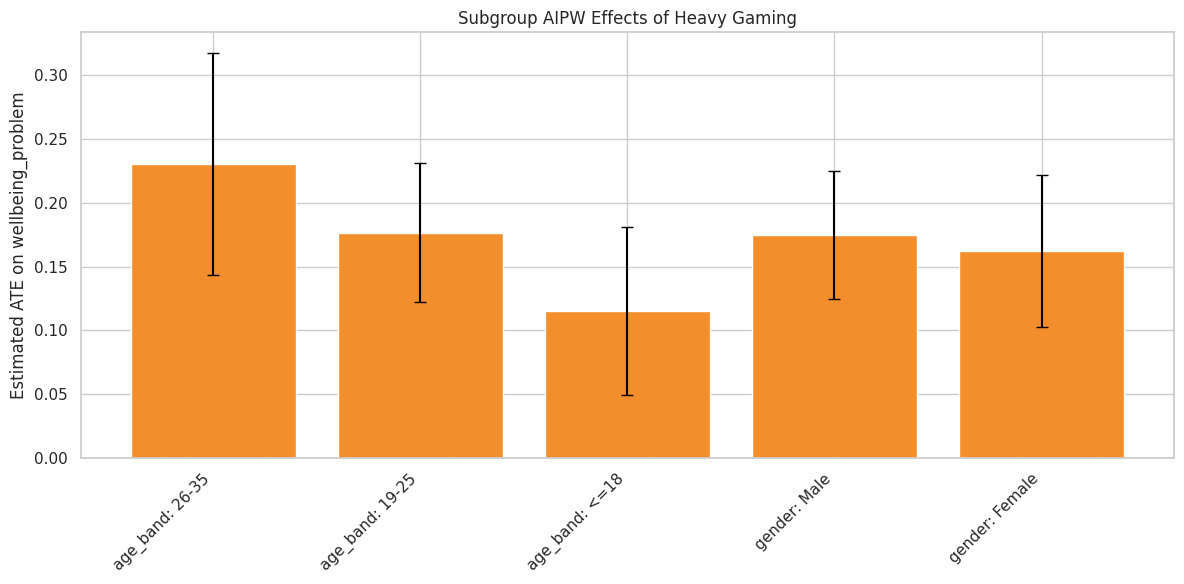

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = subgroup_df.copy()
plot_df["label"] = plot_df["group_type"] + ": " + plot_df["group"]

ax.bar(plot_df["label"], plot_df["aipw_ate"], color="#F28E2B")
ax.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["aipw_ate"],
    yerr=[plot_df["aipw_ate"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["aipw_ate"]],
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylabel("Estimated ATE on wellbeing_problem")
ax.set_title("Subgroup AIPW Effects of Heavy Gaming")
plt.tight_layout()
plt.show()


## 8) Personalized risk report + what-if simulator

This section turns the trained best model into a **personal analysis tool**:

- Score one user profile for current wellbeing-problem risk.
- Show risk band and profile summary.
- Simulate practical interventions (reduce gaming, increase exercise, reduce spending) and estimate risk deltas.

> Intended for self-monitoring and coaching support, not medical diagnosis.


In [16]:
def risk_band(p: float) -> str:
    if p < 0.20:
        return "Low"
    if p < 0.40:
        return "Moderate"
    if p < 0.60:
        return "High"
    return "Very High"


def score_single_profile(profile: dict, model_pipeline, feature_columns):
    row = {c: profile.get(c, np.nan) for c in feature_columns}
    X_one = pd.DataFrame([row])
    proba = float(model_pipeline.predict_proba(X_one)[:, 1][0])
    pred = int(proba >= 0.5)
    return {
        "predicted_label": pred,
        "risk_probability": proba,
        "risk_band": risk_band(proba),
        "input_profile": row,
    }


def simulate_what_if(base_profile: dict, model_pipeline, feature_columns):
    scenarios = {
        "baseline": {},
        "gaming_hours_-2": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 2.0)},
        "gaming_hours_-4": {"daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 4.0)},
        "exercise_+2h": {"exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0) + 2.0},
        "spending_-30pct": {"monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0) * 0.7)},
        "combined_healthy_shift": {
            "daily_gaming_hours": max(0.0, base_profile.get("daily_gaming_hours", 0) - 3.0),
            "exercise_hours_weekly": base_profile.get("exercise_hours_weekly", 0) + 2.0,
            "monthly_game_spending_usd": max(0.0, base_profile.get("monthly_game_spending_usd", 0) * 0.8),
        },
    }

    rows = []
    baseline_prob = None
    for name, updates in scenarios.items():
        profile = dict(base_profile)
        profile.update(updates)
        scored = score_single_profile(profile, model_pipeline, feature_columns)
        p = scored["risk_probability"]
        if name == "baseline":
            baseline_prob = p
        rows.append({
            "scenario": name,
            "risk_probability": p,
            "risk_band": scored["risk_band"],
        })

    out = pd.DataFrame(rows)
    out["delta_vs_baseline"] = out["risk_probability"] - float(out.loc[out["scenario"] == "baseline", "risk_probability"].iloc[0])
    return out.sort_values("risk_probability", ascending=False).reset_index(drop=True)


# Example personal profile (replace values with real user data).
example_profile = {
    "age": 23,
    "gender": "Male",
    "daily_gaming_hours": 9.0,
    "game_genre": "MOBA",
    "primary_game": "League of Legends",
    "gaming_platform": "PC",
    "monthly_game_spending_usd": 110.0,
    "years_gaming": 8.0,
    "exercise_hours_weekly": 1.0,
}

personal_result = score_single_profile(example_profile, best_pipe, feature_cols)
print("Personal risk summary:")
print({
    "predicted_label": personal_result["predicted_label"],
    "risk_probability": round(personal_result["risk_probability"], 4),
    "risk_band": personal_result["risk_band"],
})

what_if_df = simulate_what_if(example_profile, best_pipe, feature_cols)
what_if_df

Personal risk summary:
{'predicted_label': 1, 'risk_probability': 0.6773, 'risk_band': 'Very High'}


,scenario,risk_probability,risk_band,delta_vs_baseline
0,baseline,0.677323,Very High,0.000000
1,exercise_+2h,0.677323,Very High,0.000000
2,gaming_hours_-2,0.422599,High,-0.254724
3,spending_-30pct,0.297868,Moderate,-0.379455
4,gaming_hours_-4,0.015941,Low,-0.661381
5,combined_healthy_shift,0.007847,Low,-0.669476


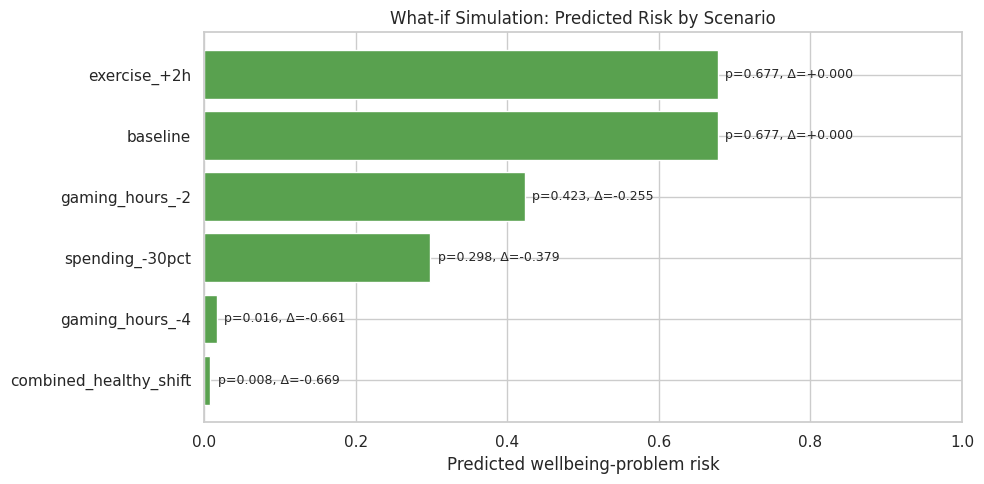

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = what_if_df.sort_values("risk_probability", ascending=True)
colors = ["#E15759" if x > 0 else "#59A14F" for x in plot_df["delta_vs_baseline"]]

ax.barh(plot_df["scenario"], plot_df["risk_probability"], color=colors)
for i, (p, d) in enumerate(zip(plot_df["risk_probability"], plot_df["delta_vs_baseline"])):
    ax.text(min(p + 0.01, 0.96), i, f"p={p:.3f}, Δ={d:+.3f}", va="center", fontsize=9)

ax.set_xlim(0, 1)
ax.set_xlabel("Predicted wellbeing-problem risk")
ax.set_title("What-if Simulation: Predicted Risk by Scenario")
plt.tight_layout()
plt.show()

## 7) Interpretation

In [18]:
best_row = results_df.iloc[0].to_dict()
top_features = perm_df.head(5)["feature"].tolist()

def pp(x):
    return f"{100*x:.1f}pp"

print("=== Predictive Performance ===")
print(f"Best model: {best_model_name}")
print(f"F1: {best_row['f1']:.3f} | ROC-AUC: {best_row['roc_auc']:.3f} | Accuracy: {best_row['accuracy']:.3f}")

print("\n=== Causal Detection (Heavy Gaming -> Wellbeing Problem) ===")
print(f"Naive ATE: {naive_ate:.4f} ({pp(naive_ate)})")
print(f"IPTW ATE:  {iptw_ate:.4f} ({pp(iptw_ate)})")
print(f"AIPW ATE:  {aipw_ate:.4f} ({pp(aipw_ate)})")
print(f"AIPW 95% CI: ({aipw_ci[0]:.4f}, {aipw_ci[1]:.4f})")

if aipw_ate > 0:
    direction = "higher"
else:
    direction = "lower"

print("\nInterpretation:")
print(
    f"After adjustment for observed confounders, heavy gaming is associated with {abs(aipw_ate)*100:.1f} percentage-point {direction} risk of wellbeing problems."
)
print("Top predictive drivers (permutation importance):")
for f in top_features:
    print(f" - {f}")

print("\nCaution: this is observational data. The causal estimate is adjusted but not guaranteed to remove unobserved confounding.")

final_summary = {
    "best_model": best_model_name,
    "best_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
    "target_prevalence": float(df["wellbeing_problem"].mean()),
    "heavy_gaming_threshold_hours": float(treatment_threshold),
    "heavy_gaming_rate": float(T.mean()),
    "causal_effects": {
        "naive_ate": float(naive_ate),
        "iptw_ate": float(iptw_ate),
        "aipw_ate": float(aipw_ate),
        "aipw_ci_low": float(aipw_ci[0]),
        "aipw_ci_high": float(aipw_ci[1]),
    },
    "top_features": top_features,
}

print("\nFINAL_RESULTS_JSON=" + json.dumps(final_summary, sort_keys=True))


=== Predictive Performance ===
Best model: XGBoost
F1: 0.671 | ROC-AUC: 0.899 | Accuracy: 0.816

=== Causal Detection (Heavy Gaming -> Wellbeing Problem) ===
Naive ATE: 0.5773 (57.7pp)
IPTW ATE:  0.0984 (9.8pp)
AIPW ATE:  0.1634 (16.3pp)
AIPW 95% CI: (0.1251, 0.2017)

Interpretation:
After adjustment for observed confounders, heavy gaming is associated with 16.3 percentage-point higher risk of wellbeing problems.
Top predictive drivers (permutation importance):
 - daily_gaming_hours
 - monthly_game_spending_usd
 - primary_game
 - age
 - game_genre

Caution: this is observational data. The causal estimate is adjusted but not guaranteed to remove unobserved confounding.

FINAL_RESULTS_JSON={"best_metrics": {"accuracy": 0.816, "f1": 0.6714285714285714, "precision": 0.6527777777777778, "recall": 0.6911764705882353, "roc_auc": 0.8989980607627667}, "best_model": "XGBoost", "causal_effects": {"aipw_ate": 0.16339597122904492, "aipw_ci_high": 0.20173503137472903, "aipw_ci_low": 0.12505691108336